In [1]:
# Librerías necesarias para descarga de datos financieros,
# manipulación de series temporales y cálculo numérico
import yfinance as yf
import pandas as pd
import numpy as np

In [2]:
# --- Cartera oficial del TFG ---
# Cinco activos de distintas clases para garantizar diversificación:
#   - Renta variable: S&P 500 (^GSPC)
#   - Materias primas: Oro (GC=F) y Petróleo crudo WTI (CL=F)
#   - Divisas: Euro/Dólar (EURUSD=X)
#   - Renta fija: ETF de bonos del Tesoro EE.UU. a 7-10 años (IEF)
tickers = {
    "SP500": "^GSPC",
    "Gold": "GC=F",
    "Oil": "CL=F",
    "EURUSD": "EURUSD=X",
    "IEF": "IEF"   # ETF bonos 7–10Y
}

start_date = "2005-01-01"   # inicio del período histórico completo
end_date = "2024-12-31"     # fin del período de evaluación

# Descargamos precios de cierre ajustados vía Yahoo Finance
# auto_adjust=True incorpora ajustes por splits y dividendos automáticamente
# threads=False evita problemas de concurrencia en entornos locales
data = yf.download(
    list(tickers.values()),
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False,
    threads=False
)

# Nos quedamos solo con los precios de cierre (descartamos Open, High, Low, Volume)
data = data["Close"]

In [3]:
# Diagnóstico de valores ausentes por activo y rango temporal de los datos
# Los NaN se producen por festivos distintos en cada mercado (p.ej. petróleo cierra algunos días que el S&P no)
print(data.isna().sum())

print(data.index.min())
print(data.index.max())

Ticker
CL=F        187
EURUSD=X     28
GC=F        191
IEF         184
^GSPC       184
dtype: int64
2005-01-03 00:00:00
2024-12-30 00:00:00


In [4]:
# Inspección de las primeras filas para verificar que la descarga es correcta
data.head()

Ticker,CL=F,EURUSD=X,GC=F,IEF,^GSPC
Date,,,,,
2005-01-03,42.119999,1.347001,428.700012,48.091404,1202.079956
2005-01-04,43.910000,1.328198,428.500000,47.791985,1188.050049
2005-01-05,43.389999,1.328004,426.600006,47.871078,1183.739990
2005-01-06,45.560001,1.318305,421.000000,47.916225,1187.890015
2005-01-07,45.430000,1.306097,418.899994,47.876732,1186.189941


In [5]:
# Renombramos columnas: sustituimos los tickers de Yahoo Finance por nombres legibles
data.columns = tickers.keys()

In [6]:
# Eliminamos filas con algún NaN: garantiza que todos los activos tienen precio
# en cada fecha. Se pierden ~187 observaciones (días en que algún mercado no cotizó).
data = data.dropna()

print("Observaciones finales:", data.shape)

Observaciones finales: (4994, 5)


In [7]:
# Calculamos rendimientos logarítmicos diarios: r_t = ln(P_t / P_{t-1})
# Los log-retornos son aditivos en el tiempo y aproximadamente normales para
# períodos cortos, lo que facilita la agregación temporal de la cartera.
returns = np.log(data / data.shift(1)).dropna()

c:\Users\GONZA\projects\TFG\.venv\Lib\site-packages\pandas\core\internals\blocks.py:347: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


In [8]:
# Cartera equiponderada: peso del 20% en cada uno de los 5 activos
# Este esquema de ponderación igual evita sesgos de selección y refleja
# una estrategia de diversificación neutral.
weights = np.array([0.2] * 5)

# Rendimiento diario del portfolio: producto escalar w' * r_t
# El resultado es la media ponderada de los log-retornos individuales
portfolio_returns = returns @ weights

In [9]:
# Definimos la pérdida como el opuesto del rendimiento: L_t = -rp_t
# Convenio de pérdidas positivas: L_t > 0 → el portfolio pierde dinero ese día
# Este convenio facilita la interpretación del VaR como umbral de pérdida
loss = -portfolio_returns

In [10]:
# Verificación de los primeros valores de la serie de pérdidas
# Valores negativos → ganancias; valores positivos → pérdidas
loss.head()

Date
2005-01-04   -0.001822
2005-01-05    0.003697
2005-01-06   -0.006540
2005-01-07    0.003884
2005-01-10   -0.001063
dtype: float64

In [11]:
# Variable objetivo: pérdida del día SIGUIENTE (L_{t+1})
# El modelo aprende a predecir qué pérdida puede ocurrir mañana usando
# información disponible hoy (features de hoy). Esto simula la predicción
# del VaR en tiempo real sin data leakage.
loss_t_plus_1 = loss.shift(-1)
loss_t_plus_1 = loss_t_plus_1.dropna()  # el último día no tiene pérdida futura → NaN

In [12]:
# Construcción de los 15 retardos del rendimiento de la cartera como features
# rp_lag_0 = rendimiento de hoy, rp_lag_1 = ayer, ..., rp_lag_14 = hace 14 días
# Capturan la dinámica temporal: autocorrelación, momentum y reversión a la media
k = 15

lagged_returns = pd.concat(
    [portfolio_returns.shift(i) for i in range(k)],
    axis=1
)

lagged_returns.columns = [f"rp_lag_{i}" for i in range(k)]

In [13]:
# Volatilidades realizadas a dos horizontes temporales:
#   vol_20 ≈ volatilidad mensual  (ventana de 20 días hábiles)
#   vol_60 ≈ volatilidad trimestral (ventana de 60 días hábiles)
# Estas features capturan el régimen de riesgo actual de la cartera.
# ddof=0 → desviación típica poblacional (más estable con ventanas pequeñas)
vol_20 = portfolio_returns.rolling(20).std(ddof=0)
vol_60 = portfolio_returns.rolling(60).std(ddof=0)

vol_20.name = "vol_20"
vol_60.name = "vol_60"

vol_20

Date
2005-01-04         NaN
2005-01-05         NaN
2005-01-06         NaN
2005-01-07         NaN
2005-01-10         NaN
                ...   
2024-12-23    0.004671
2024-12-24    0.004237
2024-12-26    0.004237
2024-12-27    0.004211
2024-12-30    0.004167
Name: vol_20, Length: 4991, dtype: float64

In [14]:
# Renombramos los rendimientos individuales para distinguirlos de los
# retardos del portfolio en la matriz de features final
returns_renamed = returns.copy()
returns_renamed.columns = [f"{col}_ret" for col in returns.columns]

In [15]:
# Concatenamos todos los features en una única matriz X con 22 columnas:
#   - 15 retardos del rendimiento de la cartera  (contexto histórico)
#   - 2 volatilidades realizadas                  (régimen de riesgo)
#   - 5 rendimientos individuales del día         (composición de la cartera)
X = pd.concat(
    [lagged_returns, vol_20, vol_60, returns_renamed],
    axis=1
)

In [16]:
# Unimos features (X) con la variable objetivo (L_{t+1}) y eliminamos NaNs
# Los NaN aparecen en las primeras filas por los retardos (k=15) y las
# volatilidades rolling (ventana=60), así como en el último día (target shift)
dataset = pd.concat([X, loss_t_plus_1.rename("target")], axis=1)
dataset = dataset.dropna()

In [17]:
# Dataset final: 4,931 observaciones × 22 features + 1 target
# Abarca desde abril 2005 hasta finales de 2024
print(dataset.shape)
print(dataset.head())

(4931, 23)
            rp_lag_0  rp_lag_1  rp_lag_2  rp_lag_3  rp_lag_4  rp_lag_5  \
Date                                                                     
2005-04-01  0.003535  0.010017  0.000671 -0.003072  0.002595 -0.011626   
2005-04-04 -0.002319  0.003535  0.010017  0.000671 -0.003072  0.002595   
2005-04-05 -0.002108 -0.002319  0.003535  0.010017  0.000671 -0.003072   
2005-04-06  0.001734 -0.002108 -0.002319  0.003535  0.010017  0.000671   
2005-04-07 -0.006451  0.001734 -0.002108 -0.002319  0.003535  0.010017   

            rp_lag_6  rp_lag_7  rp_lag_8  rp_lag_9  ...  rp_lag_13  rp_lag_14  \
Date                                                ...                         
2005-04-01 -0.006801 -0.007782 -0.000046 -0.001830  ...   0.002984  -0.002587   
2005-04-04 -0.011626 -0.006801 -0.007782 -0.000046  ...  -0.000403   0.002984   
2005-04-05  0.002595 -0.011626 -0.006801 -0.007782  ...  -0.002446  -0.000403   
2005-04-06 -0.003072  0.002595 -0.011626 -0.006801  ...   0.00666

In [18]:
# Verificación de consistencia: el target del dataset debe coincidir exactamente
# con el shift manual de la serie de pérdidas. Ambos valores deben ser iguales.
print(dataset["target"].loc[dataset.index[0]])
print(loss.shift(-1).loc[dataset.index[0]])

0.0023194372368764526
0.0023194372368764526


In [19]:
# Guardamos el dataset completo en formato pickle para su uso eficiente
# en los notebooks de modelado (ANN, GARCH, HS)
dataset.to_pickle("../data/dataset_tfg.pkl")

Media: 0.00021488141534236894
Varianza: 5.252584567996e-05
Skewness: -0.31636814009279973
Kurtosis: 20.982130119960246
Exceso de curtosis: 17.982130119960246


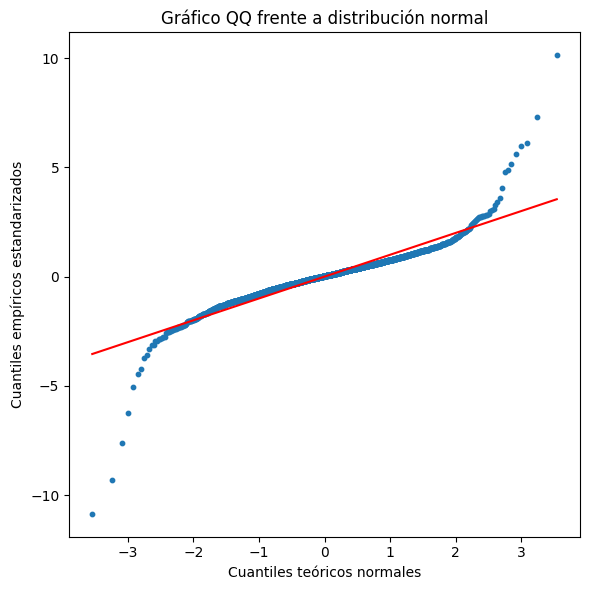

In [20]:
# =============================================================
# Análisis estadístico descriptivo del portfolio (2015-2024)
# =============================================================

# Filtramos el período de evaluación fuera de muestra
portfolio_returns_eval = portfolio_returns.loc["2015":"2024"].copy()
loss_eval = loss.loc["2015":"2024"].copy()

# Momentos estadísticos de la distribución de rendimientos del portfolio
mu       = portfolio_returns_eval.mean()
sigma    = portfolio_returns_eval.std()
variance = sigma**2
skew_emp     = portfolio_returns_eval.skew()
kurt_excess  = portfolio_returns_eval.kurt()   # exceso de curtosis (distribución normal = 0)
kurt_classic = kurt_excess + 3                 # curtosis clásica   (distribución normal = 3)

print("Media:", mu)
print("Varianza:", variance)
print("Skewness:", skew_emp)
print("Kurtosis:", kurt_classic)
print("Exceso de curtosis:", kurt_excess)

import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Estandarizamos los rendimientos para comparar con cuantiles teóricos normales
z = (portfolio_returns_eval - portfolio_returns_eval.mean()) / portfolio_returns_eval.std()

# Cuantiles teóricos de la distribución normal estándar
theoretical_quantiles = np.sort(stats.norm.ppf(
    (np.arange(1, len(z)+1) - 0.5) / len(z)
))

# Cuantiles empíricos ordenados de menor a mayor
empirical_quantiles = np.sort(z)

# Gráfico QQ frente a la Normal:
# - Si los puntos siguen la diagonal roja → distribución normal perfecta
# - Desviaciones en las colas (fat tails) indican curtosis > 3, evidencia de
#   riesgo extremo subestimado por modelos con supuesto de normalidad
plt.figure(figsize=(6,6))
plt.scatter(theoretical_quantiles, empirical_quantiles, s=10)

# Línea de referencia: diagonal perfecta = normalidad exacta
plt.plot(theoretical_quantiles, theoretical_quantiles, color='red')

plt.title("Gráfico QQ frente a distribución normal")
plt.xlabel("Cuantiles teóricos normales")
plt.ylabel("Cuantiles empíricos estandarizados")

plt.tight_layout()
plt.savefig("qq_portfolio.png")
plt.show()

In [21]:
# =============================================================
# Test de Jarque-Bera de normalidad (período 2015-2024)
# =============================================================
# H0: los rendimientos siguen una distribución normal
# Estadístico JB ~ chi²(2) bajo H0
jb_stat, jb_pvalue = stats.jarque_bera(portfolio_returns_eval)
jb_df = 2  # grados de libertad del test (siempre 2: skewness + exceso curtosis)

print(f"Estadístico JB : {jb_stat:.6f}")
print(f"p-valor        : {jb_pvalue:.2e}")
print(f"Grados libertad: {jb_df}")

Estadístico JB : 33675.612444
p-valor        : 0.00e+00
Grados libertad: 2


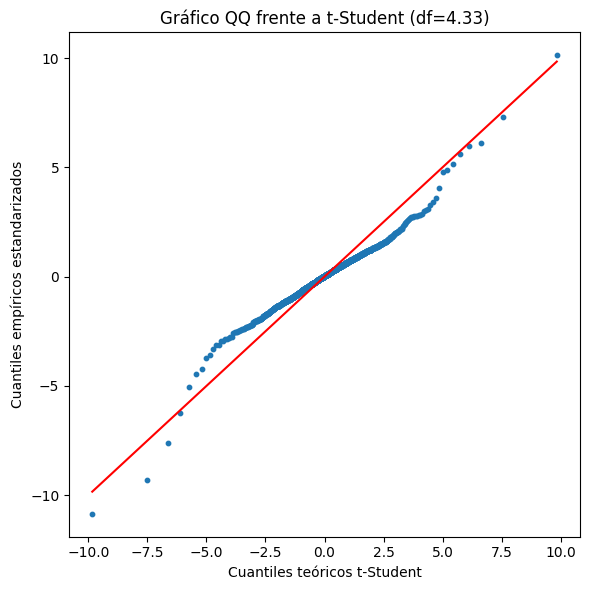

In [22]:
# =============================================================
# QQ plot frente a distribución t-Student
# =============================================================
# La t-Student tiene colas más pesadas que la normal, lo que la hace
# más adecuada para modelar rendimientos financieros con fat tails.

# Estimamos los grados de libertad a partir del exceso de curtosis empírico.
# Relación analítica: para t(ν) → curtosis_exceso = 6/(ν-4) → ν = 4 + 6/kurt_excess
nu = 4 + 6 / kurt_excess

# Cuantiles teóricos de la t-Student con ν grados de libertad estimados
theoretical_quantiles_t = np.sort(stats.t.ppf(
    (np.arange(1, len(z)+1) - 0.5) / len(z),
    df=nu
))

# Un mejor ajuste respecto al gráfico Normal confirma la presencia de fat tails
plt.figure(figsize=(6,6))
plt.scatter(theoretical_quantiles_t, empirical_quantiles, s=10)

# Línea de referencia: diagonal perfecta = t-Student exacta con df=ν
plt.plot(theoretical_quantiles_t, theoretical_quantiles_t, color='red')

plt.title(f"Gráfico QQ frente a t-Student (df={nu:.2f})")
plt.xlabel("Cuantiles teóricos t-Student")
plt.ylabel("Cuantiles empíricos estandarizados")

plt.tight_layout()
plt.savefig("qq_portfolio_tstudent.png")
plt.show()

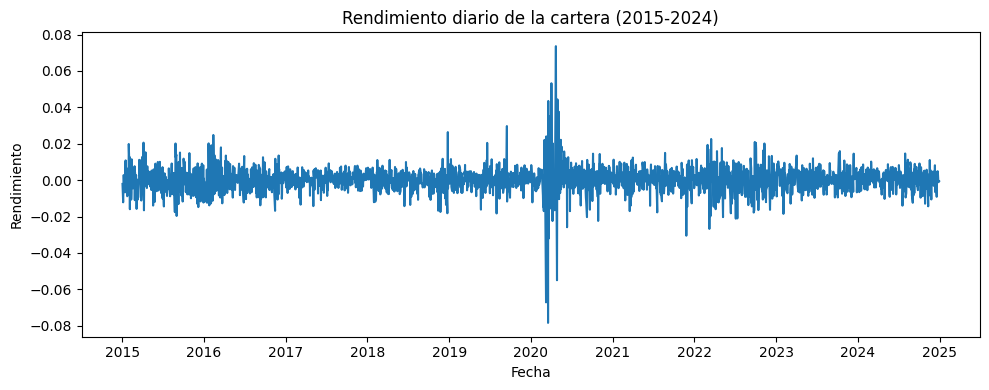

In [23]:
# Serie temporal de rendimientos diarios del portfolio (período de evaluación)
# Permite identificar visualmente episodios de alta volatilidad:
# - Crisis COVID-19 (marzo 2020): mayor cluster de volatilidad
# - Crisis de tipos de 2022: pérdidas sostenidas
plt.figure(figsize=(10,4))
plt.plot(portfolio_returns_eval)
plt.title("Rendimiento diario de la cartera (2015-2024)")
plt.xlabel("Fecha")
plt.ylabel("Rendimiento")
plt.tight_layout()
plt.show()